# **Decision Tree Regressor**
> Dataset: `BostonHousing.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
df.shape

(506, 14)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


### **EDA**

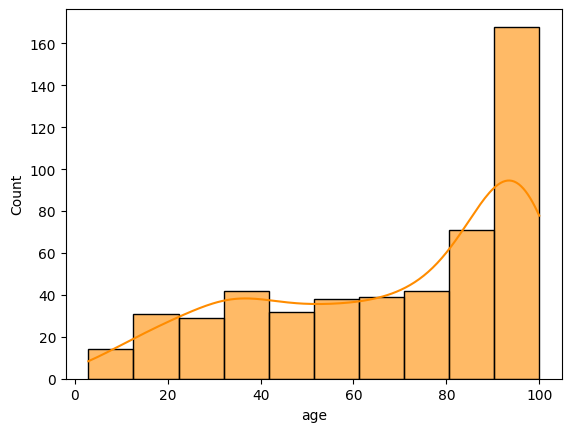

In [5]:
# age distribution
sns.histplot(df['age'], kde = True, color = 'darkorange', alpha = 0.6)
plt.show()

<Axes: >

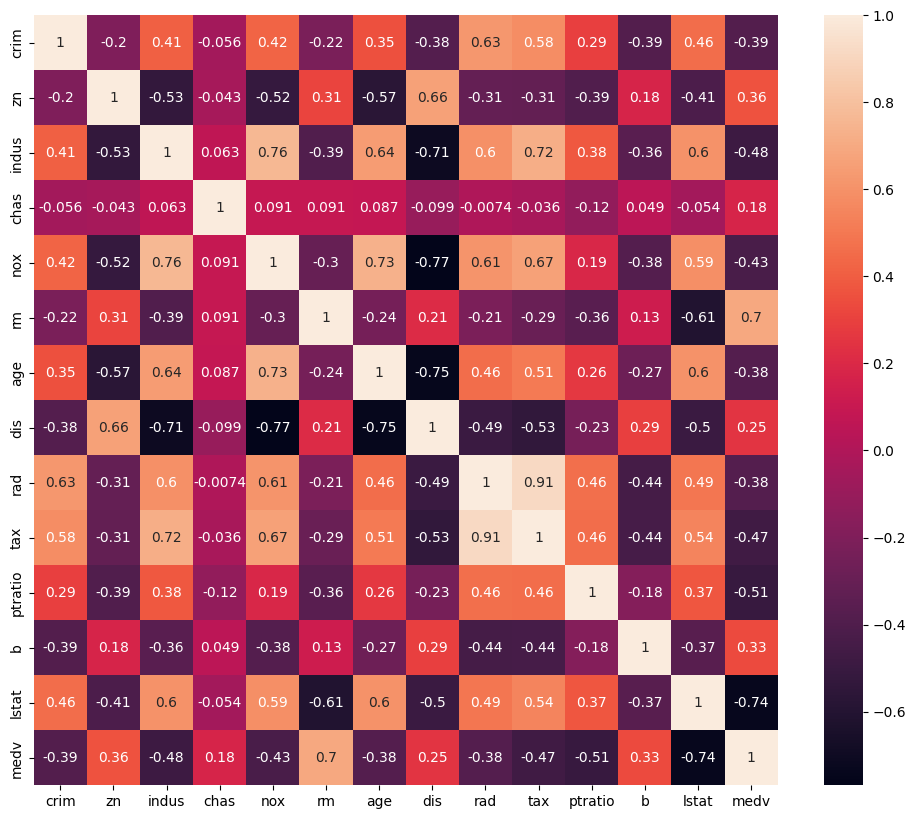

In [6]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr().T, annot = True, cmap = 'rocket')

### **Cleaning**

In [7]:
# null values
df.isna().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [8]:
# duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
# outliers
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)

iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr


outliers = (df < lower_bound) | (df > upper_bound)
print(outliers.sum())

crim       66
zn         68
indus       0
chas       35
nox         0
rm         30
age         0
dis         5
rad         0
tax         0
ptratio    15
b          77
lstat       7
medv       40
dtype: int64


In [10]:
# Remove rows containing outliers
df = df[~outliers.any(axis=1)]
print(df.shape)

(268, 14)


### **Transformation and Pipelines**

### **Recommended Transformation/Scaling Methods per Column**

| Column  | Recommended Method (in order)   |
| :------ | :------------------------------ |
| `crim`  | Log1p, StandardScaler             |
| `zn`    | Log1p, StandardScaler             |
| `indus` | StandardScaler                  |
| `chas`  | No scaling/transformation needed |
| `nox`   | StandardScaler                  |
| `rm`    | StandardScaler                  |
| `age`   | StandardScaler                  |
| `dis`   | StandardScaler                  |
| `rad`   | StandardScaler                  |
| `tax`   | StandardScaler                  |
| `ptratio`| StandardScaler                  |
| `b`     | StandardScaler                  |
| `lstat` | Log1p, StandardScaler             |
| `medv`  | No scaling/transformation needed (for now, as target for tree-based models) |


In [11]:
# trasformation and scaling
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,FunctionTransformer

no_needed = ['chas']
both = ['crim','zn','lstat']
just_scaling = ['indus','nox','rm','age','dis','rad','tax','ptratio','b']


feature_cols = no_needed + both + just_scaling
x = df[feature_cols]
y = df['medv']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [12]:
# applying the pipelines

# both pipeline
both_pipeline = Pipeline(
    steps = [
        ('transform', FunctionTransformer(np.log1p, validate=True)),
        ('scale', StandardScaler())
    ]
)

# Just scaling
just_scaling_pipeline = Pipeline(
    steps = [
        ('scale', StandardScaler())
    ]
)

In [13]:
# Preprocessing Pipeline
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers = [
    ('both_transform_and_scale', both_pipeline, both),
    ('just_scaling', just_scaling_pipeline, just_scaling) # Corrected column assignment
], remainder='passthrough') # Add remainder='passthrough' to keep other columns like 'chas'

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('both_transform_and_scale',
                                 Pipeline(steps=[('transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>,
                                                                      validate=True)),
                                                 ('scale', StandardScaler())]),
                                 ['crim', 'zn', 'lstat']),
                                ('just_scaling',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['indus', 'nox', 'rm', 'age', 'dis', 'rad',
                                  'tax', 'ptratio', 'b'])])

In [14]:
# model training
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV


# hyper-parameter tuning
param_grid = {
    'Regression__criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'Regression__max_depth': [3, 5, 7, 10, 15, None],
    'Regression__min_samples_split': [2, 5, 10],
    'Regression__min_samples_leaf': [1, 2, 4],
    'Regression__max_features': [None, 'sqrt', 'log2']
}


model = Pipeline(
    steps = [
        ('Preprocess',preprocessor),
        ('Regression',DecisionTreeRegressor())
    ])


grid = GridSearchCV(
    estimator = model,
    cv = 5,
    param_grid = param_grid,
    n_jobs = -1,
    scoring = 'r2',
    verbose = 1
)

grid.fit(x_train, y_train)


# best stuff
print('best hyperparameters : ',grid.best_params_)
print('best score : ',grid.best_score_)
print('best estimator : ',grid.best_estimator_)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
best hyperparameters :  {'Regression__criterion': 'absolute_error', 'Regression__max_depth': 10, 'Regression__max_features': None, 'Regression__min_samples_leaf': 2, 'Regression__min_samples_split': 2}
best score :  0.622920830023258
best estimator :  Pipeline(steps=[('Preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('both_transform_and_scale',
                                                  Pipeline(steps=[('transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>,
                                                                                       validate=True)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['crim',

In [15]:
dt_best = grid.best_estimator_
y_pred_best = dt_best.predict(x_test)
print('R2 score (Decision Tree tuned) : ',r2_score(y_test, y_pred_best))

R2 score (Decision Tree tuned) :  0.5718697718449081


In [18]:
# decision tree without hyperparameter tuning
dt = Pipeline(
    steps = [
        ('preprocessor',preprocessor),
        ('regressor',DecisionTreeRegressor())
    ]
)

dt.fit(x_train, y_train)
y_Pred = dt.predict(x_test)

# R2 score
print('R2 score (Decision Tree default) : ',r2_score(y_test, y_Pred))

R2 score (Decision Tree default) :  0.5864114262726365


# Default Performs better ⚡️